# Pitcher Context and Bat-Tracking Analysis

In [24]:
!pip install pybaseball

---
## [SECTION A] Setup & Data Collection


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pybaseball import statcast
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings, os

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

os.makedirs("data", exist_ok=True)
print("Packages loaded")

Packages loaded


In [26]:
# Collect Statcast pitch-level data
CACHE = "data/statcast_2025.csv"

MONTHS = [
    ("2025-03-28","2025-04-30"), ("2025-05-01","2025-05-31"),
    ("2025-06-01","2025-06-30"), ("2025-07-01","2025-07-31"),
    ("2025-08-01","2025-08-31"), ("2025-09-01","2025-09-30"),
]

if os.path.exists(CACHE):
    raw = pd.read_csv(CACHE, low_memory=False)
    print(f"Loaded from cache: {len(raw):,} rows")
else:
    print("Fetching from Baseball Savant (first run only, ~15–20 min)...")
    frames = []
    for s, e in MONTHS:
        try:
            df = statcast(start_dt=s, end_dt=e)
            frames.append(df)
            print(f"  {s} → {e}: {len(df):,} rows")
        except Exception as ex:
            print(f"  {s} → {e} error: {ex}")
    raw = pd.concat(frames, ignore_index=True)
    raw.to_csv(CACHE, index=False)
    print(f"Saved {len(raw):,} rows → {CACHE}")

# Common filters; feet → inches
pitches = raw[raw["pitch_type"].notna()].copy()
pitches["pfx_x_in"] = pitches["pfx_x"] * 12
pitches["pfx_z_in"] = pitches["pfx_z"] * 12

BAT_COL = "bat_speed"
AA_COL  = "attack_angle"
has_bat = BAT_COL in pitches.columns and pitches[BAT_COL].notna().sum() > 0
swings  = pitches[pitches[BAT_COL].notna()].copy() if has_bat else pd.DataFrame()

print(f"\nTotal pitches with pitch type: {len(pitches):,}")
print(f"Bat-tracking swings: {len(swings):,}  (has_bat={has_bat})")

Loaded from cache: 708,693 rows

Total pitches with pitch type: 706,091
Bat-tracking swings:           327,534  (has_bat=True)


---
## [SECTION B] Pitcher Arsenal Clustering
**Purpose:** Cluster pitchers by pitch-mix, velocity, and movement to create grouping labels  
**Output:** `data/pitcher_cluster_labels.csv`  

In [27]:
# Compute pitcher-level arsenal features
def build_arsenal_features(df):
    totals = df.groupby("pitcher").size().rename("n_pitches")

    pt = (df.groupby(["pitcher","pitch_type"]).size()
            .unstack(fill_value=0))
    pt = pt.div(pt.sum(axis=1), axis=0)

    ff = [c for c in pt.columns if c in ["FF","SI","FC"]]
    br = [c for c in pt.columns if c in ["SL","CU","KC","SV","ST"]]
    os_ = [c for c in pt.columns if c in ["CH","FS","FO","SC"]]

    feat = pd.DataFrame(index=pt.index)
    feat["pct_fastball"] = pt[ff].sum(axis=1)  if ff  else 0
    feat["pct_breaking"] = pt[br].sum(axis=1)  if br  else 0
    feat["pct_offspeed"] = pt[os_].sum(axis=1) if os_ else 0

    agg = df.groupby("pitcher").agg(
        avg_velo = ("release_speed","mean"),
        avg_pfx_x = ("pfx_x_in","mean"),
        avg_pfx_z = ("pfx_z_in","mean"),
        velo_spread = ("release_speed",
                       lambda x: x.quantile(0.9)-x.quantile(0.1)),
    )
    result = feat.join(agg).join(totals)
    return result[result["n_pitches"] >= 200].dropna()

arsenal = build_arsenal_features(pitches)
print(f"Pitchers with ≥200 pitches: {len(arsenal)}")

Pitchers with ≥200 pitches: 639


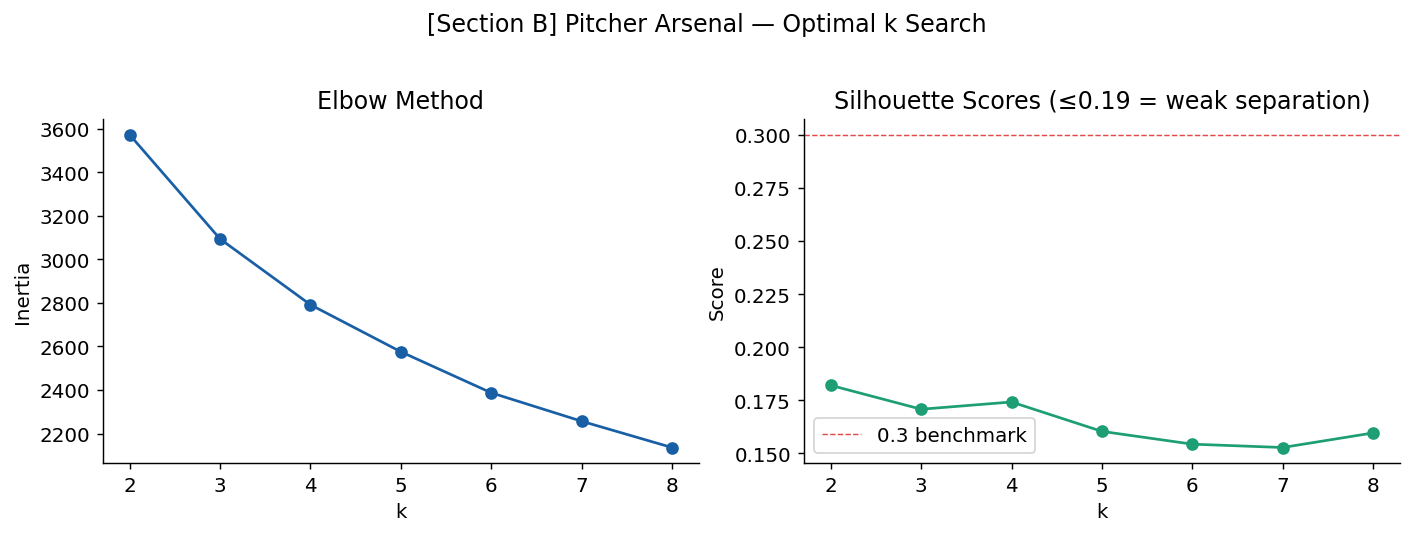

Max silhouette: 0.182  (k=2)
 = All values ≤ 0.19: no well-separated clusters — MLB arsenals form a continuous spectrum


In [28]:
# K-Means: Elbow + Silhouette
FEATS = ["pct_fastball","pct_breaking","pct_offspeed", "avg_velo","avg_pfx_x","avg_pfx_z","velo_spread"]

Xa = StandardScaler().fit_transform(arsenal[FEATS])
inertias, sils = [], []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(Xa)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xa, lbl))

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].plot(range(2,9), inertias, "o-", color="#185FA5")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(range(2,9), sils, "o-", color="#1D9E75")
axes[1].axhline(0.3, color="#E24B4A", linestyle="--", linewidth=0.8, label="0.3 benchmark")
axes[1].set_title("Silhouette Scores (≤0.19 = weak separation)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score"); axes[1].legend()
plt.suptitle("[Section B] Pitcher Arsenal — Optimal k Search", y=1.02)
plt.tight_layout()
plt.savefig("data/fig_B1_arsenal_elbow.png", bbox_inches="tight")
plt.show()

print(f"Max silhouette: {max(sils):.3f}  (k={range(2,9)[sils.index(max(sils))]})")
print(" = All values ≤ 0.19: no well-separated clusters — MLB arsenals form a continuous spectrum")

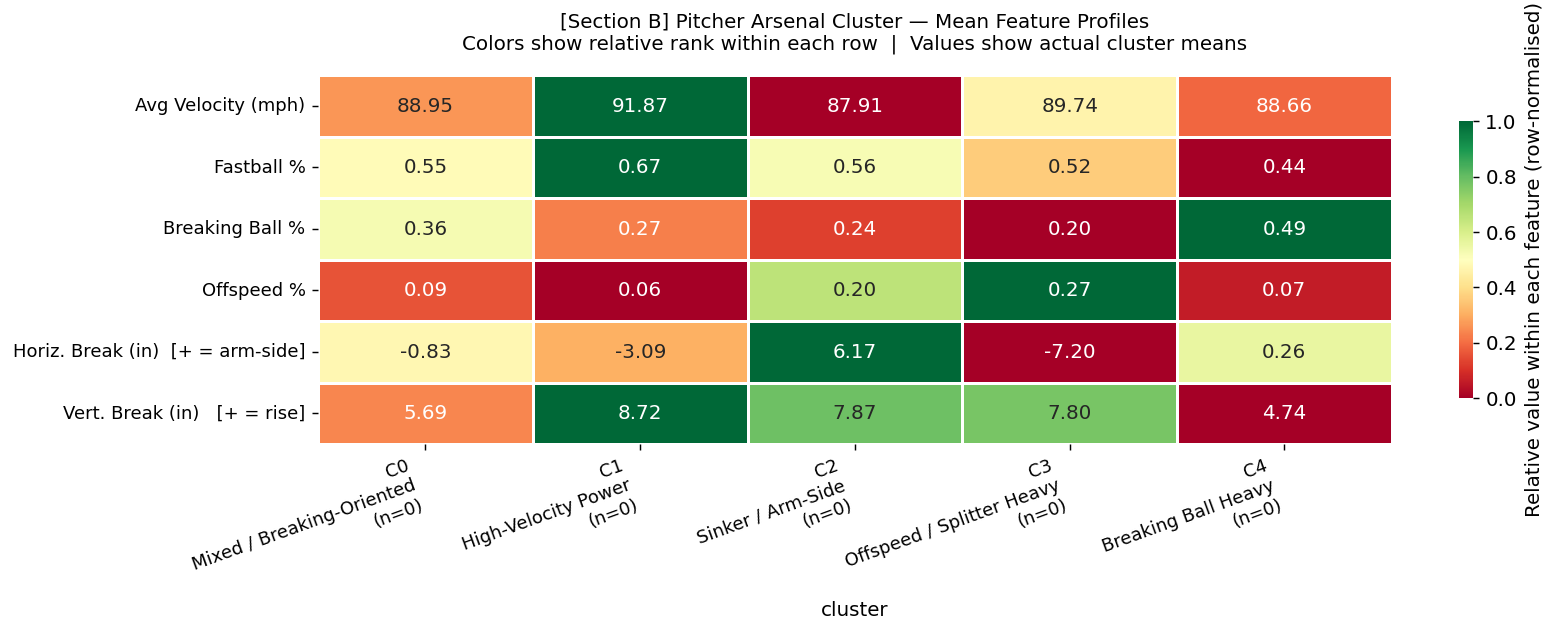

In [33]:
import numpy as np

HM_COLS = ["avg_velo","pct_fastball","pct_breaking",
           "pct_offspeed","avg_pfx_x","avg_pfx_z"]

ROW_LABELS = {
    "avg_velo":       "Avg Velocity (mph)",
    "pct_fastball":   "Fastball %",
    "pct_breaking":   "Breaking Ball %",
    "pct_offspeed":   "Offspeed %",
    "avg_pfx_x":      "Horiz. Break (in)  [+ = arm-side]",
    "avg_pfx_z":      "Vert. Break (in)   [+ = rise]",
}

hm_raw  = prof[HM_COLS].T.astype(float)
hm_norm = hm_raw.apply(
    lambda row: (row - row.min()) / (row.max() - row.min() + 1e-9),
    axis=1
)

xlabels = [
    f"C{c}\n{labels_map.get(c,'')}\n(n={int(clusters_b[clusters_b['cluster']==c].shape[0])})"
    for c in prof.index
]
ylabels = [ROW_LABELS.get(c, c) for c in HM_COLS]

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    hm_norm,
    annot=hm_raw,
    fmt=".2f",
    cmap="RdYlGn",
    xticklabels=xlabels,
    yticklabels=ylabels,
    ax=ax,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Relative value within each feature (row-normalised)",
              "shrink": 0.75}
)

ax.set_title(
    "[Section B] Pitcher Arsenal Cluster — Mean Feature Profiles\n"
    "Colors show relative rank within each row  |  Values show actual cluster means",
    fontsize=11, pad=14
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("data/fig_B2_arsenal_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## [SECTION C] Pitcher Movement Profile Clustering
**Purpose:** Cluster pitchers by horizontal (pfx_x) and vertical (pfx_z) movement direction  
**Output:** `data/pitcher_movement_labels.csv`  


In [34]:
# Compute pitcher-level movement profiles
mov = pitches[pitches["pfx_x"].notna() & pitches["pfx_z"].notna()].copy()
movement = mov.groupby("pitcher").agg(
    n_pitches = ("pitch_type","count"),
    wt_pfx_x  = ("pfx_x_in","mean"),
    wt_pfx_z  = ("pfx_z_in","mean"),
    avg_velo  = ("release_speed","mean"),
).query("n_pitches >= 200").dropna()

print(f"Pitchers with movement profiles: {len(movement)}")
print(f"pfx_x range: {movement.wt_pfx_x.min():.1f} to {movement.wt_pfx_x.max():.1f} inches")
print(f"pfx_z range: {movement.wt_pfx_z.min():.1f} to {movement.wt_pfx_z.max():.1f} inches")
print(f"pfx_x < 0 (glove-side): {(movement.wt_pfx_x<0).sum()} "
      f"({(movement.wt_pfx_x<0).mean()*100:.0f}%) — reflects RHP majority")

Pitchers with movement profiles: 639
pfx_x range: -16.1 to 16.7 inches
pfx_z range: -6.2 to 16.9 inches
pfx_x < 0 (glove-side): 411 (64%) — reflects RHP majority


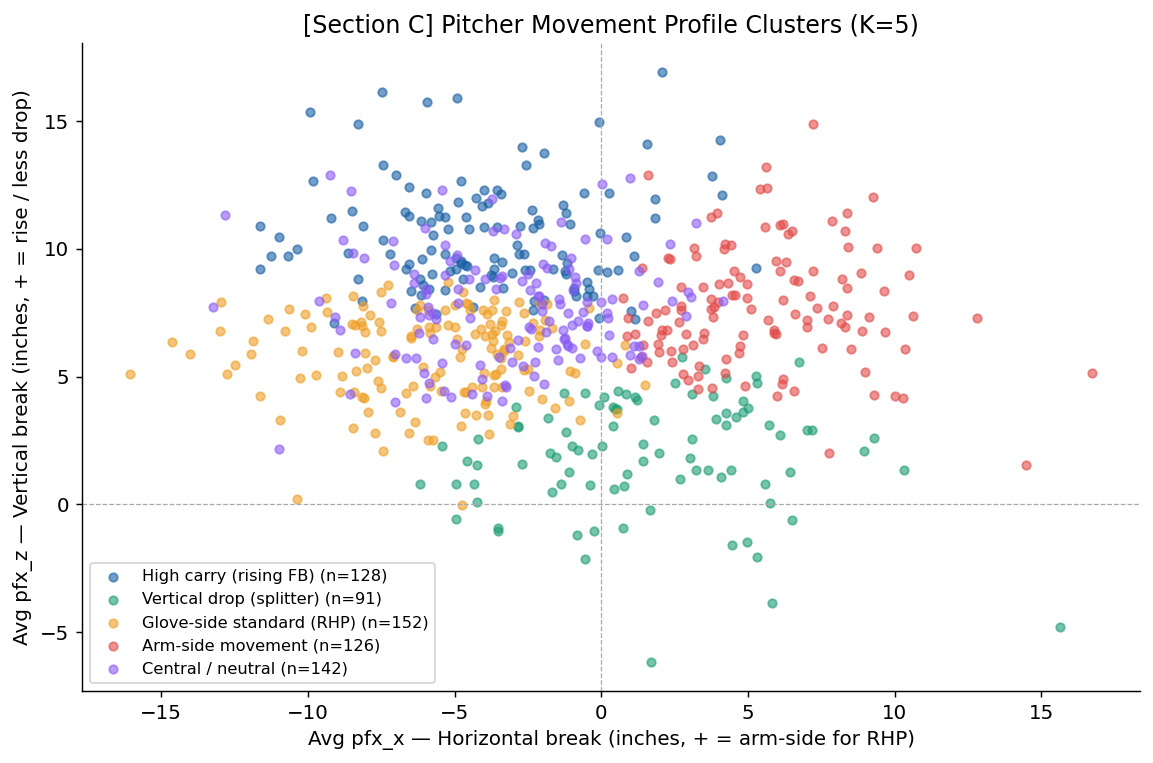


Cluster profiles:
                                         n  pfx_x  pfx_z   velo
mov_cluster mov_archetype                                      
0           High carry (rising FB)     128  -3.88  10.44  92.40
1           Vertical drop (splitter)    91   1.64   1.93  87.24
2           Glove-side standard (RHP)  152  -5.75   5.76  91.05
3           Arm-side movement          126   5.47   7.71  89.31
4           Central / neutral          142  -3.11   7.63  87.36

 Saved: data/pitcher_movement_labels.csv


In [35]:
# K-Means clustering with corrected label conditions
MOV_FEATS = ["wt_pfx_x","wt_pfx_z","avg_velo"]
Xm = StandardScaler().fit_transform(movement[MOV_FEATS])

km_m = KMeans(n_clusters=5, random_state=42, n_init=20)
movement["mov_cluster"] = km_m.fit_predict(Xm).astype(str)

# Corrected labeling logic (pfx_z priority — more discriminating)
mp = movement.groupby("mov_cluster")[MOV_FEATS].mean()
mov_label = {}
for cl, row in mp.iterrows():
    if row["wt_pfx_z"] > 9.0:
        mov_label[cl] = "High carry (rising FB)"
    elif row["wt_pfx_z"] < 5.0:
        mov_label[cl] = "Vertical drop (splitter)"
    elif row["wt_pfx_x"] > 3.0:
        mov_label[cl] = "Arm-side movement"
    elif row["wt_pfx_x"] < -4.0:
        mov_label[cl] = "Glove-side standard (RHP)"
    else:
        mov_label[cl] = "Central / neutral"

movement["mov_archetype"] = movement["mov_cluster"].map(mov_label)

# Cluster scatter plot
CMOV = {"0":"#185FA5","1":"#1D9E75","2":"#EF9F27","3":"#E24B4A","4":"#8B5CF6"}
fig, ax = plt.subplots(figsize=(9,6))
for cl in sorted(movement["mov_cluster"].unique()):
    s = movement[movement["mov_cluster"]==cl]
    ax.scatter(s["wt_pfx_x"], s["wt_pfx_z"],
               c=CMOV.get(cl,"#888"), alpha=0.6, s=22,
               label=f'{mov_label.get(cl,cl)} (n={len(s)})')
ax.axhline(0, color="#aaa", linewidth=0.7, linestyle="--")
ax.axvline(0, color="#aaa", linewidth=0.7, linestyle="--")
ax.set_xlabel("Avg pfx_x — Horizontal break (inches, + = arm-side for RHP)")
ax.set_ylabel("Avg pfx_z — Vertical break (inches, + = rise / less drop)")
ax.set_title("[Section C] Pitcher Movement Profile Clusters (K=5)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("data/fig_C1_movement_clusters.png", bbox_inches="tight")
plt.show()

# Cluster summary table
summary_c = movement.groupby(["mov_cluster","mov_archetype"]).agg(
    n=("n_pitches","count"),
    pfx_x=("wt_pfx_x","mean"),
    pfx_z=("wt_pfx_z","mean"),
    velo=("avg_velo","mean")
).round(2)
print("\nCluster profiles:")
print(summary_c.to_string())

movement.reset_index()[["pitcher","mov_cluster","mov_archetype",
                         "n_pitches","wt_pfx_x","wt_pfx_z","avg_velo"]].to_csv(
    "data/pitcher_movement_labels.csv", index=False)
print("\n Saved: data/pitcher_movement_labels.csv")

---
## [SECTION D] Per-Pitcher Sample Size Analysis
**Purpose:** Demonstrate why individual pitcher-level analysis is unreliable,  
and quantify the sample size improvement from cluster-level aggregation  
**Output:** `data/batter_by_pitcher_cluster.csv`  


In [37]:
# ── Load data and join cluster labels from Section B ─────────────
if not has_bat:
    print(" bat_speed column not found — Sections D/E require 2024+ Statcast data")
else:
    clusters_b = pd.read_csv("data/pitcher_cluster_labels.csv")
    sw = swings.merge(clusters_b[["pitcher","cluster","archetype"]],
                      on="pitcher", how="left")
    print(f"Bat-tracking swings: {len(sw):,}")
    print(f"Swings with cluster label: {sw['cluster'].notna().sum():,}")

Bat-tracking swings: 327,534
Swings with cluster label: 319,193


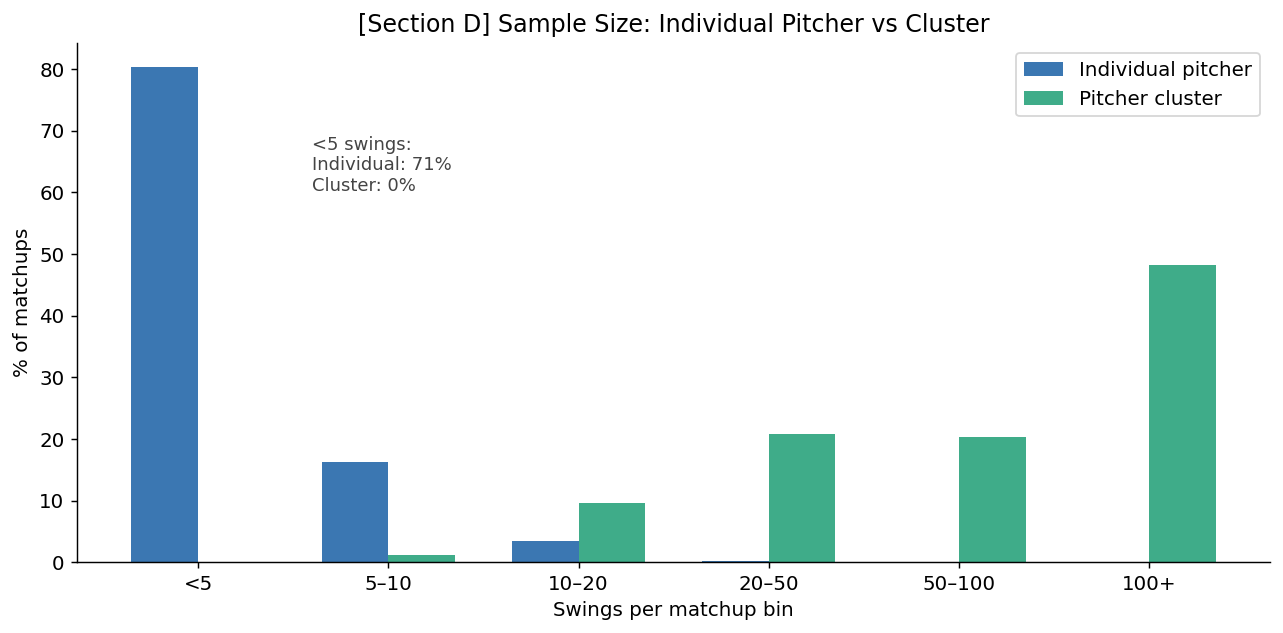

Individual pitcher — <5 swings: 71.4%
Pitcher cluster    — <5 swings: 0.0%
Pitcher cluster    — ≥50 swings: 69.2%  (reliability threshold not met)

 Saved: data/batter_by_pitcher_cluster.csv


In [38]:
# Sample size comparison: individual pitcher vs cluster
if has_bat:
    matchup_ind = (sw.groupby(["batter","pitcher"])
                   .agg(n_swings=(BAT_COL,"count")).reset_index())

    matchup_cl = (sw[sw["cluster"].notna()]
                  .groupby(["batter","cluster"])
                  .agg(n_swings      = (BAT_COL,"count"),
                       avg_bat_speed = (BAT_COL,"mean"),
                       avg_aa        = (AA_COL,"mean")
                                       if AA_COL in sw.columns
                                       else (BAT_COL,"count"),
                       ideal_aa_rate = (AA_COL,
                                        lambda x: ((x>=5)&(x<=20)).mean())
                                       if AA_COL in sw.columns
                                       else (BAT_COL, lambda x: np.nan))
                  .reset_index())
    matchup_cl = matchup_cl[matchup_cl["n_swings"] >= 10]

    # Grouped bar comparison
    bins    = [0,5,10,20,50,100,9999]
    blabels = ["<5","5–10","10–20","20–50","50–100","100+"]
    ind_pct = pd.cut(matchup_ind["n_swings"], bins, labels=blabels
                     ).value_counts(normalize=True).sort_index()*100
    cl_pct  = pd.cut(matchup_cl["n_swings"],  bins, labels=blabels
                     ).value_counts(normalize=True).sort_index()*100

    x = np.arange(len(blabels)); w = 0.35
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(x-w/2, ind_pct.reindex(blabels,fill_value=0), w,
           label="Individual pitcher", color="#185FA5", alpha=0.85)
    ax.bar(x+w/2, cl_pct.reindex(blabels,fill_value=0),  w,
           label="Pitcher cluster",    color="#1D9E75", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(blabels)
    ax.set_xlabel("Swings per matchup bin")
    ax.set_ylabel("% of matchups")
    ax.set_title("[Section D] Sample Size: Individual Pitcher vs Cluster")
    ax.legend()

    p5_ind = (matchup_ind["n_swings"]<5).mean()*100
    p5_cl  = (matchup_cl["n_swings"]<5).mean()*100
    p50_cl = (matchup_cl["n_swings"]>=50).mean()*100
    ax.annotate(f"<5 swings:\nIndividual: {p5_ind:.0f}%\nCluster: {p5_cl:.0f}%",
                xy=(0, max(ind_pct.iloc[0], cl_pct.iloc[0])),
                xytext=(0.6, max(ind_pct.iloc[0], cl_pct.iloc[0])*0.75),
                fontsize=10, color="#444")
    plt.tight_layout()
    plt.savefig("data/fig_D1_sample_comparison.png", bbox_inches="tight")
    plt.show()

    print(f"Individual pitcher — <5 swings: {p5_ind:.1f}%")
    print(f"Pitcher cluster    — <5 swings: {p5_cl:.1f}%")
    print(f"Pitcher cluster    — ≥50 swings: {p50_cl:.1f}%  "
          f"(reliability threshold not met)")

    matchup_cl.to_csv("data/batter_by_pitcher_cluster.csv", index=False)
    print("\n Saved: data/batter_by_pitcher_cluster.csv")

---
## [SECTION E] Illustrative Case Analysis
**Purpose:** Visualise how ideal_AA_rate varies across pitcher clusters  
for power-type vs contact-type hitter archetypes

In [45]:
# Load season-aggregate data for hitter archetype classification
SUMMARY = "data/dashboard_ready_swing_quality_scores.csv"

if not has_bat:
    print("Bat-tracking data not available — skipping Section E")
elif not os.path.exists(SUMMARY):
    print(f"{SUMMARY} not found.")
    batter_summary = swings.groupby("batter").agg(
        n_swings      = (BAT_COL,"count"),
        avg_bat_speed = (BAT_COL,"mean"),
        ideal_aa_rate = (AA_COL, lambda x: ((x>=5)&(x<=20)).mean())
                        if AA_COL in swings.columns else (BAT_COL, lambda x: np.nan),
    ).query("n_swings >= 100")
    print(f"  Aggregated: {len(batter_summary)} hitters")
else:
    batter_summary = pd.read_csv(SUMMARY)
    batter_summary = batter_summary.rename(columns={"id":"batter"})
    batter_summary["batter"] = batter_summary["batter"].astype(int)
    print(f"Season summary data: {len(batter_summary)} hitters")

Season summary data: 587 hitters


In [48]:
# define power-type / contact-type batter pool
if has_bat and "batter_summary" in dir():
    bs = batter_summary.copy()

    # categorizing standard
    spd_hi  = bs["avg_bat_speed"].quantile(0.80)   # top 20% = power-type
    spd_lo  = bs["avg_bat_speed"].quantile(0.40)   # bottom 40% = contact-type
    aa_hi   = bs["ideal_attack_angle_rate"].quantile(0.70)
    aa_lo   = bs["ideal_attack_angle_rate"].quantile(0.40)

    power_pool   = bs[(bs["avg_bat_speed"]>=spd_hi)&(bs["ideal_attack_angle_rate"]<=aa_lo)]
    contact_pool = bs[(bs["avg_bat_speed"]<=spd_lo)&(bs["ideal_attack_angle_rate"]>=aa_hi)]

    print(f"Power-type batter pool:   {len(power_pool)}  (bat_speed \u2265 {spd_hi:.1f}mph, ideal_AA \u2264 {aa_lo:.2f})")
    print(f"Contact-type batter pool:  {len(contact_pool)}  (bat_speed \u2264 {spd_lo:.1f}mph, ideal_AA \u2265 {aa_hi:.2f})")

    # Pick maximum three from each pool (competitive_swings)
    sw_col = "competitive_swings" if "competitive_swings" in bs.columns else "n_swings"
    a_ids = power_pool.reset_index().nlargest(min(3,len(power_pool)), sw_col)["batter"].tolist()
    b_ids = contact_pool.reset_index().nlargest(min(3,len(contact_pool)), sw_col)["batter"].tolist()
    print(f"\n Selected power-type batter ID:  {a_ids}")
    print(f" Selected contact-type batter ID: {b_ids}")

Power-type batter pool:   53  (bat_speed ≥ 73.7mph, ideal_AA ≤ 0.49)
Contact-type batter pool:  73  (bat_speed ≤ 71.0mph, ideal_AA ≥ 0.55)

 Selected power-type batter ID:  [663728, 621566, 682985]
 Selected contact-type batter ID: [645277, 641355, 621020]


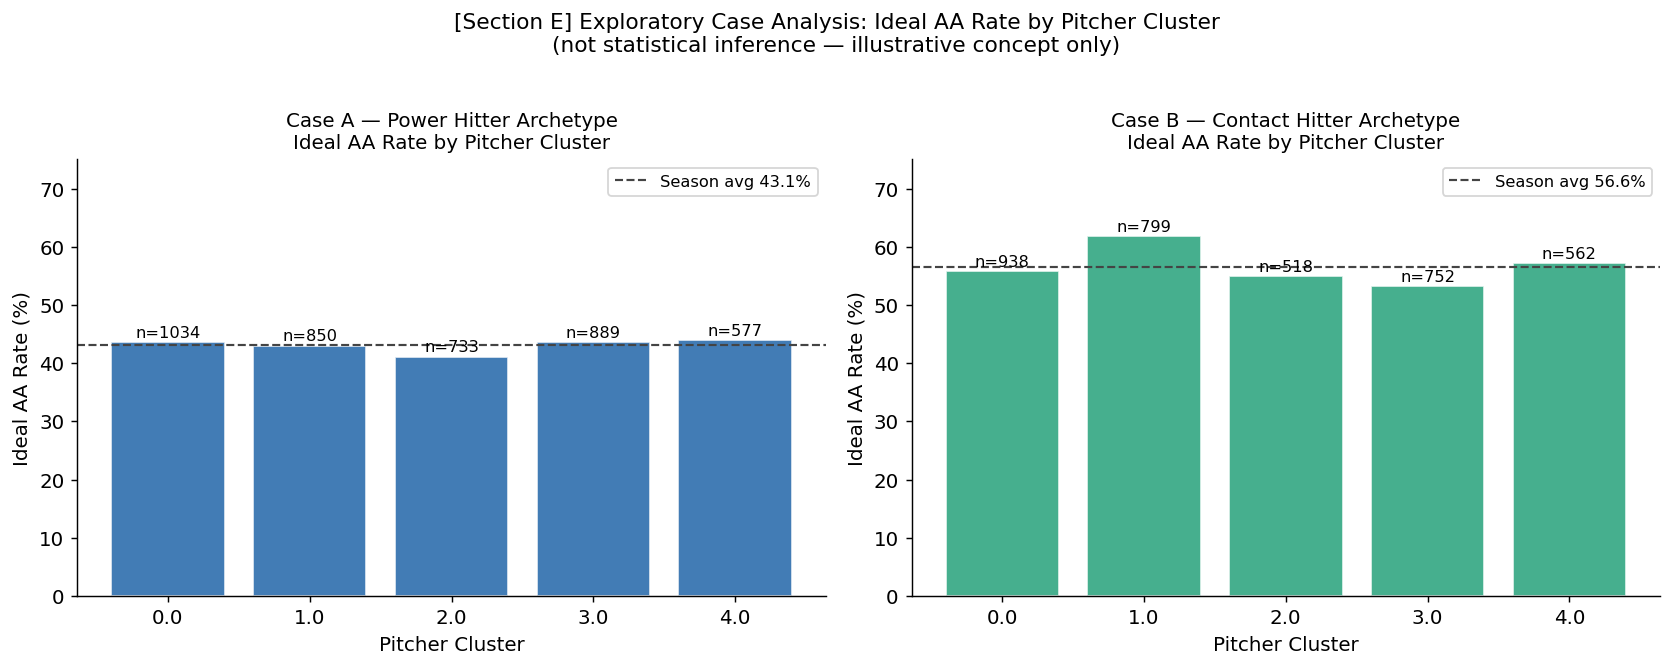

In [49]:
# Cluster-level ideal_AA_rate comparison
if has_bat and "matchup_cl" in dir() and "a_ids" in dir():
    bc = pd.read_csv("data/batter_by_pitcher_cluster.csv")

    def get_cluster_profile(batter_ids, case_label, color, ax):
        subset = bc[bc["batter"].isin(batter_ids) & (bc["n_swings"]>=10)]
        if subset.empty:
            ax.text(0.5,0.5,"No data available",
                    transform=ax.transAxes, ha="center"); return

        agg = subset.groupby("cluster").agg(
            ideal_aa_rate = ("ideal_aa_rate","mean"),
            n_total       = ("n_swings","sum")
        ).reset_index()

        bars = ax.bar(agg["cluster"].astype(str), agg["ideal_aa_rate"]*100,
                      color=color, alpha=0.82, edgecolor="white")
        for bar, row in zip(bars, agg.itertuples()):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.3,
                    f"n={row.n_total}", ha="center", va="bottom", fontsize=9)

        season_avg = subset["ideal_aa_rate"].mean()*100
        ax.axhline(season_avg, color="#444", linestyle="--", linewidth=1.2,
                   label=f"Season avg {season_avg:.1f}%")
        ax.set_title(f"{case_label}\nIdeal AA Rate by Pitcher Cluster", fontsize=11)
        ax.set_xlabel("Pitcher Cluster"); ax.set_ylabel("Ideal AA Rate (%)")
        ax.legend(fontsize=9); ax.set_ylim(0,75)

    fig, axes = plt.subplots(1,2, figsize=(13,5))
    get_cluster_profile(a_ids, "Case A — Power Hitter Archetype",  "#185FA5", axes[0])
    get_cluster_profile(b_ids, "Case B — Contact Hitter Archetype","#1D9E75", axes[1])

    fig.suptitle("[Section E] Exploratory Case Analysis: Ideal AA Rate by Pitcher Cluster\n"
                 "(not statistical inference — illustrative concept only)",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig("data/fig_E1_illustrative_case.png", bbox_inches="tight")
    plt.show()
else:
    print(" Batter classification data not available — skipping visualisation")